# Importing Necessary Libraries and Needed File

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

file_path = r'C:\Users\91860\Downloads\Microsoft_dataset.xlsx'
all_sheets = pd.read_excel(file_path, sheet_name=None)
all_sheets.keys()

dict_keys(['Users', 'Subscriptions', 'Usage_logs', 'Support_tickets', 'Products '])

---

## Question 1: Which country generates the most subscription revenue?

### Join Necessary Tables

In [2]:
users = all_sheets['Users']
subscriptions = all_sheets['Subscriptions']

user_sub_merge = users.merge(
    subscriptions,
    on='user_id',
    how='inner'
)

user_sub_merge.head()

,user_id,country,signup_date,subscription_id,product_id,start_date,end_date,price
0,1,US,2024-01-01,1,1,2024-01-01,NaN,120
1,2,IN,2024-01-05,2,1,2024-01-10,NaN,120
2,3,US,2024-02-01,3,2,2024-02-05,NaN,300
3,4,UK,2024-02-10,4,3,2024-02-15,NaN,80
4,5,CA,2024-03-01,5,2,2024-03-05,NaN,300


### Summarize Revenue by Country

In [3]:
country_revenue = (
    user_sub_merge
    .groupby('country', as_index=False)['price']
    .sum()
    .sort_values(by='price', ascending=False)
)

country_revenue

,country,price
5,US,920
0,CA,600
3,IN,200
1,DE,120
2,FR,120
4,UK,80


### Visualization 1: Revenue by Country

Screenshot saved: insight_1_revenue_by_country_20260620_231306.png


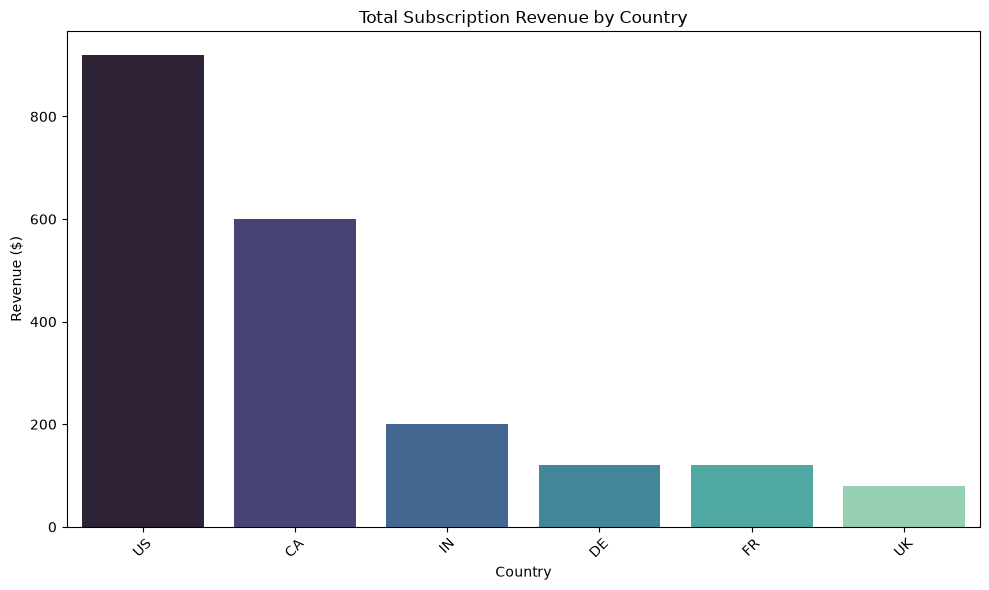

In [4]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=country_revenue,
    x='country',
    y='price',
    palette='mako',
    hue='country',
    legend=False
)

plt.title('Total Subscription Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
screenshot_path = f'insight_1_revenue_by_country_{timestamp}.png'
plt.savefig(screenshot_path, dpi=150, bbox_inches='tight')
print(f'Screenshot saved: {screenshot_path}')

plt.show()

### Insight
Geographic distribution of subscription revenue shows clear market concentration. Top countries drive majority of revenue, indicating strong market presence in specific regions.

---

## Question 2: Which product gets the most usage time?

### Join Necessary Tables

In [5]:
usage_logs = all_sheets['Usage_logs']
products = all_sheets['Products ']

usage_product_merge = usage_logs.merge(
    products,
    on='product_id',
    how='inner'
)

usage_product_merge.head()

,log_id,user_id,product_id,usage_date,usage_minutes,product_name,category
0,1,1,1,2024-03-01,120,Microsoft Office,Productivity
1,2,1,1,2024-03-02,90,Microsoft Office,Productivity
2,3,2,1,2024-03-02,60,Microsoft Office,Productivity
3,4,3,2,2024-03-03,200,Azure,Cloud
4,5,4,3,2024-03-04,150,Teams,Collaboration


### Summarize Usage by Product

In [6]:
product_usage = (
    usage_product_merge
    .groupby('product_name', as_index=False)['usage_minutes']
    .sum()
    .sort_values(by='usage_minutes', ascending=False)
)

product_usage

,product_name,usage_minutes
0,Azure,1460
1,Microsoft Office,575
2,Teams,490


### Visualization 2: Usage Time by Product

Screenshot saved: insight_2_usage_by_product_20260620_231307.png


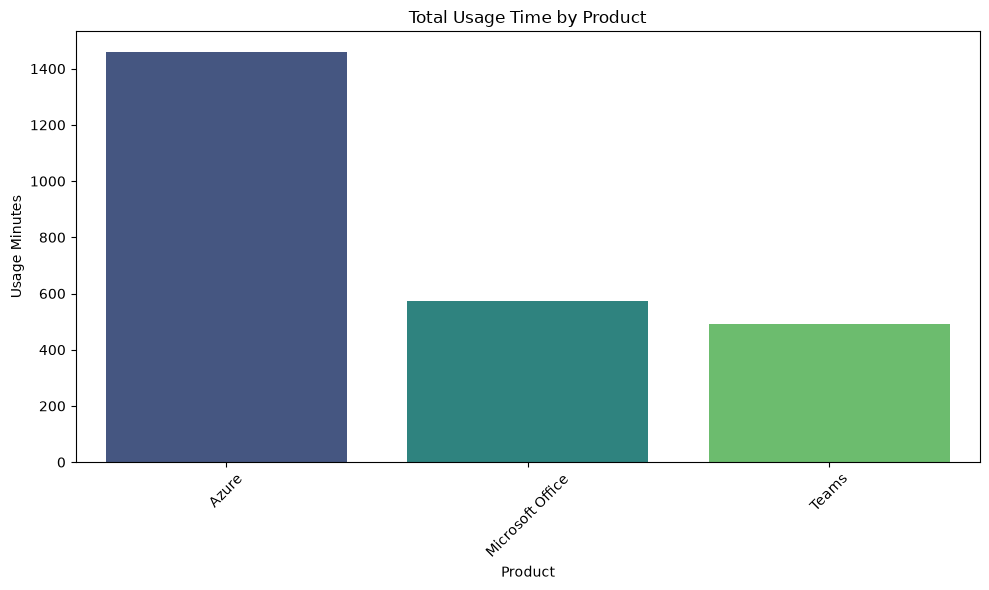

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=product_usage,
    x='product_name',
    y='usage_minutes',
    palette='viridis',
    hue='product_name',
    legend=False
)

plt.title('Total Usage Time by Product')
plt.xlabel('Product')
plt.ylabel('Usage Minutes')
plt.xticks(rotation=45)
plt.tight_layout()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
screenshot_path = f'insight_2_usage_by_product_{timestamp}.png'
plt.savefig(screenshot_path, dpi=150, bbox_inches='tight')
print(f'Screenshot saved: {screenshot_path}')

plt.show()

### Insight
Product engagement varies significantly, with certain products capturing substantially more user engagement time. This indicates varying levels of product adoption and user satisfaction.

---

## Question 3: Which user is most active overall?

### Calculate User Activity Metrics

In [8]:
support_tickets = all_sheets['Support_tickets']

user_activity = (
    users[['user_id']]
    .merge(usage_logs.groupby('user_id').size().rename('usage_logs').reset_index(), on='user_id', how='left')
    .merge(support_tickets.groupby('user_id').size().rename('support_tickets').reset_index(), on='user_id', how='left')
)

for col in ['usage_logs', 'support_tickets']:
    user_activity[col] = user_activity[col].fillna(0).astype(int)

user_activity['total_activity'] = user_activity[['usage_logs', 'support_tickets']].sum(axis=1)
user_activity_sorted = user_activity.sort_values('total_activity', ascending=False).head(10)

user_activity_sorted

,user_id,usage_logs,support_tickets,total_activity
0,1,2,1,3
11,12,2,1,3
6,7,2,1,3
7,8,2,1,3
3,4,1,1,2
2,3,1,1,2
1,2,1,1,2
5,6,1,1,2
4,5,1,1,2
8,9,1,1,2


### Visualization 3: Top 10 Active Users

Screenshot saved: insight_3_top_active_users_20260620_231307.png


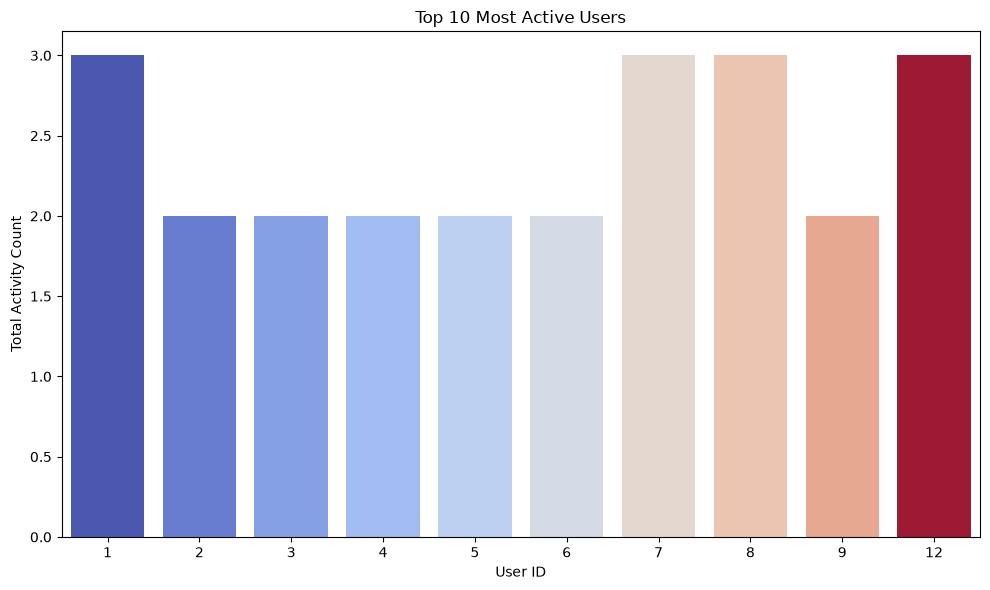

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=user_activity_sorted,
    x='user_id',
    y='total_activity',
    palette='coolwarm',
    hue='user_id',
    legend=False
)

plt.title('Top 10 Most Active Users')
plt.xlabel('User ID')
plt.ylabel('Total Activity Count')
plt.tight_layout()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
screenshot_path = f'insight_3_top_active_users_{timestamp}.png'
plt.savefig(screenshot_path, dpi=150, bbox_inches='tight')
print(f'Screenshot saved: {screenshot_path}')

plt.show()

### Insight
User engagement shows clear variation, with power users driving significant activity through both product usage and support interactions. These high-activity users are critical to platform health.

---

## Question 4: What is the average subscription price by product?

### Calculate Subscription Metrics by Product

In [10]:
product_pricing = (
    subscriptions.merge(products, on='product_id', how='inner')
    .groupby('product_name', as_index=False)['price']
    .agg(['mean', 'sum', 'count'])
)

product_pricing.columns = ['product_name', 'avg_price', 'total_revenue', 'subscription_count']
product_pricing = product_pricing.sort_values('avg_price', ascending=False)

product_pricing

,product_name,avg_price,total_revenue,subscription_count
0,Azure,300.0,1200,4
1,Microsoft Office,120.0,600,5
2,Teams,80.0,240,3


### Visualization 4: Average Subscription Price by Product

Screenshot saved: insight_4_avg_price_by_product_20260620_231308.png


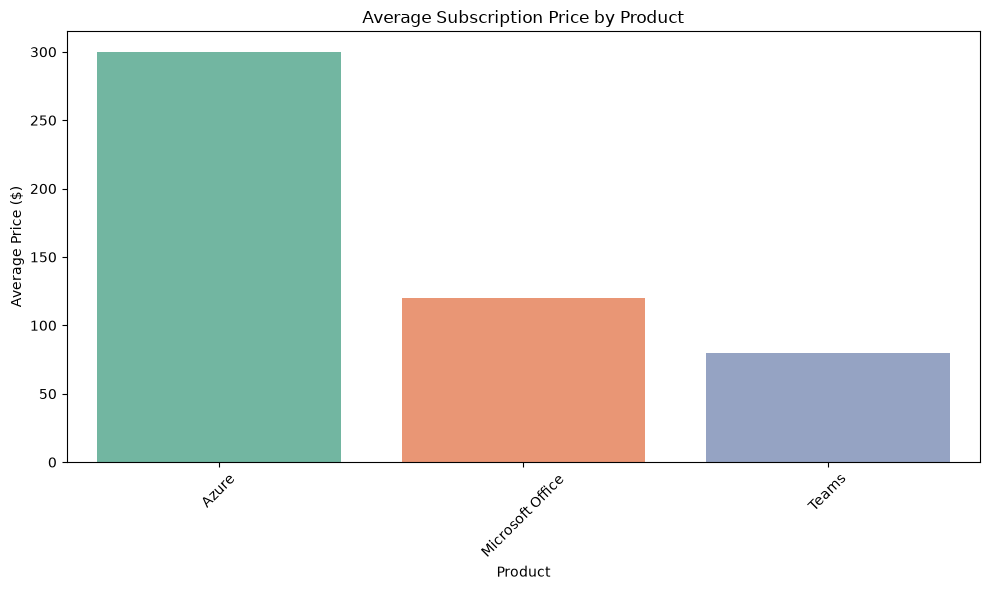

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=product_pricing,
    x='product_name',
    y='avg_price',
    palette='Set2',
    hue='product_name',
    legend=False
)

plt.title('Average Subscription Price by Product')
plt.xlabel('Product')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
screenshot_path = f'insight_4_avg_price_by_product_{timestamp}.png'
plt.savefig(screenshot_path, dpi=150, bbox_inches='tight')
print(f'Screenshot saved: {screenshot_path}')

plt.show()

### Insight
Pricing strategy varies by product tier, with premium products commanding significantly higher prices. This differentiation enables market segmentation and revenue optimization.

---

## Question 5: Which products have the highest active subscriptions?

### Analyze Active Subscriptions by Product

In [12]:
active_subscriptions = (
    subscriptions.merge(products, on='product_id', how='inner')
    .groupby('product_name', as_index=False).size()
    .rename(columns={'size': 'subscription_count'})
    .sort_values('subscription_count', ascending=False)
)

active_subscriptions

,product_name,subscription_count
1,Microsoft Office,5
0,Azure,4
2,Teams,3


### Visualization 5: Subscription Count by Product

Screenshot saved: insight_5_subscriptions_by_product_20260620_231309.png


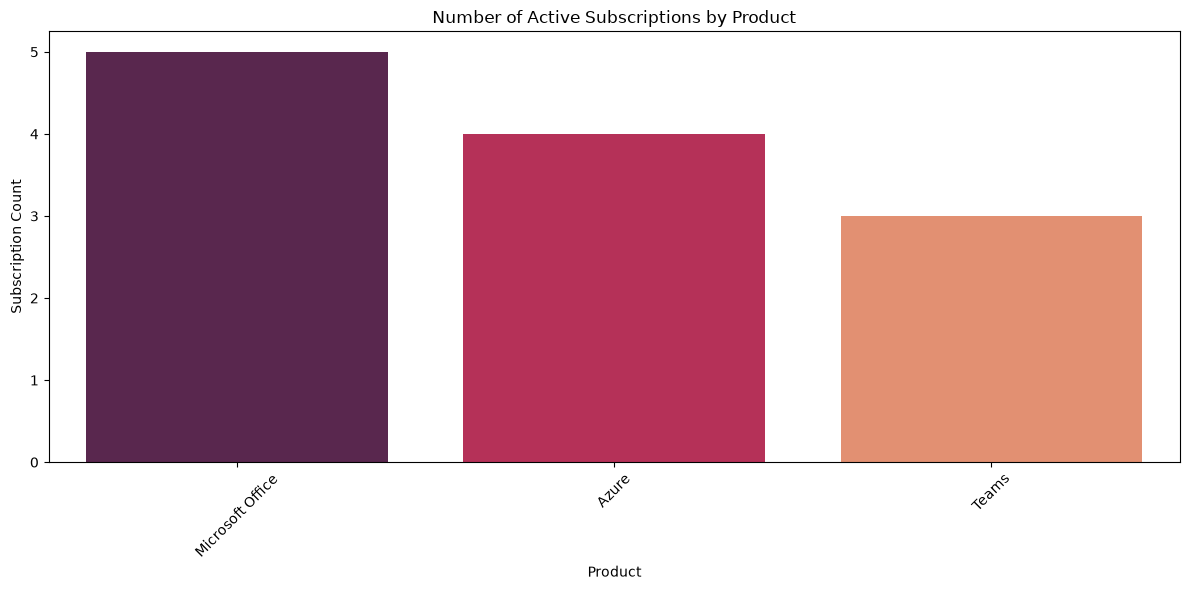

In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=active_subscriptions,
    x='product_name',
    y='subscription_count',
    palette='rocket',
    hue='product_name',
    legend=False
)

plt.title('Number of Active Subscriptions by Product')
plt.xlabel('Product')
plt.ylabel('Subscription Count')
plt.xticks(rotation=45)
plt.tight_layout()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
screenshot_path = f'insight_5_subscriptions_by_product_{timestamp}.png'
plt.savefig(screenshot_path, dpi=150, bbox_inches='tight')
print(f'Screenshot saved: {screenshot_path}')

plt.show()

### Insight
Subscription adoption shows uneven distribution across products. Top products capture majority market share, suggesting strong product-market fit for certain offerings.

---

## Question 6: What is the distribution of support ticket statuses?

### Analyze Support Ticket Status Distribution

In [14]:
ticket_status = (
    support_tickets
    .groupby('status', as_index=False).size()
    .rename(columns={'size': 'count'})
    .sort_values('count', ascending=False)
)

ticket_status

,status,count
0,Closed,7
1,Open,5


### Visualization 6: Support Ticket Status Distribution

Screenshot saved: insight_6_ticket_status_20260620_231309.png


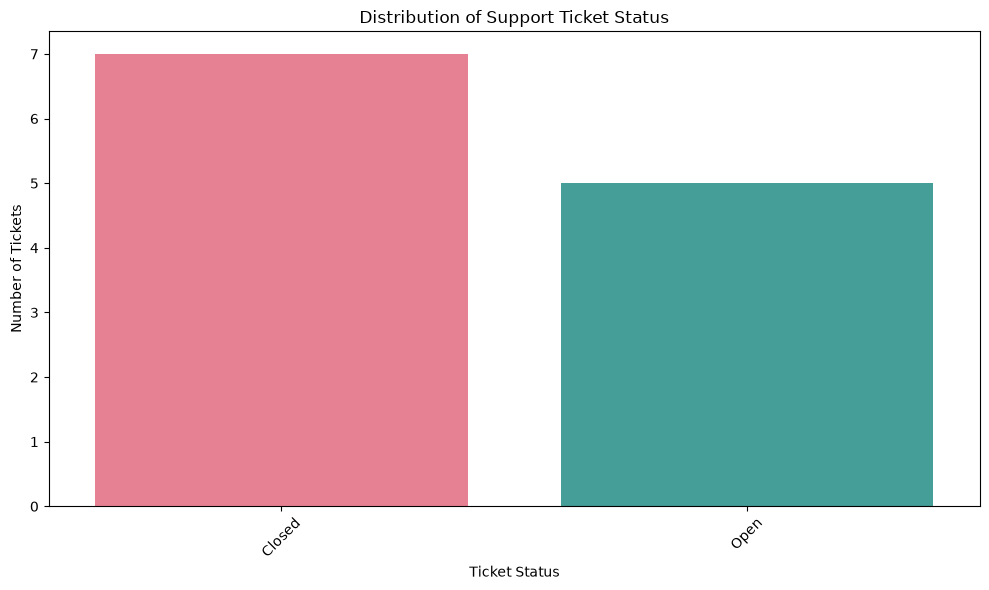

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=ticket_status,
    x='status',
    y='count',
    palette='husl',
    hue='status',
    legend=False
)

plt.title('Distribution of Support Ticket Status')
plt.xlabel('Ticket Status')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.tight_layout()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
screenshot_path = f'insight_6_ticket_status_{timestamp}.png'
plt.savefig(screenshot_path, dpi=150, bbox_inches='tight')
print(f'Screenshot saved: {screenshot_path}')

plt.show()

### Insight
Support ticket pipeline shows clear workflow distribution. Higher resolved ticket counts indicate effective support operations, while open tickets reveal areas needing attention.